In [1]:
import sys
import gym
import time
import numpy as np
import pandas as pd
import seaborn as sns
import itertools
import matplotlib.pyplot as plt
from DDPG import DDPGagent
from utils import *
from gym import spaces
from joblib import Parallel, delayed

In [2]:
TvL = .36 # tau*vel/L 6.48s*100km\hr / 500m
mean = 0 # guassian noise mean
var = 0.7 # variance

mul = .7
def dyn(x, u):
    t1,t2,t3,t4,t5 = x
    u1,u3 = u
    q = .25
    noise = np.random.normal(mean, np.sqrt(var), size = 5)
    t1n = (1-TvL)*t1 + TvL*t5 + 6*u1 + mul*noise[0]
    t2n = (1-TvL-q)*t2 + TvL*t1 + mul*noise[1]
    t3n = (1-TvL)*t3 + TvL*t2 + 8*u3 + mul*noise[2]
    t4n = (1-TvL-q)*t4 + TvL*t3 + mul*noise[3]
    t5n = (1-TvL)*t5 + TvL*t4 + mul*noise[4]
    return [t1n,t2n,t3n,t4n,t5n] 

# labelling observations
obst = [0, 10]
targ = [1, 8]
c = [obst[0], targ[0]]

# assigning labels
def Obs(sn):
    sn = np.array(sn)
    # assigning labels
    if (sn<=obst[0]).all() or (sn>=obst[1]).all(): return 'h' # unsafe
    elif (sn>=targ[0]).all() and (sn<=targ[1]).all(): return 't' # safest
    elif (sn>targ[1]).all() and (sn<obst[1]).all(): return 'm'
    elif (sn<targ[0]).all() and (sn>obst[0]).all(): return 'c' 

### pRMs

In [3]:
# for RS
# state transition and reward function
def delta_v(u, ap, k):
    q,xh,xc,xm,xt = u # q,a,c,d,b according to draft's notation
    r,r1,r2,r3 = 0,0,0,1
    if q == 0: # i.e. q0
        if ap == 'm': q,xh,xc,xm,xt,r = 1,xh+1,xc+1,0,xt+1,r2
        elif ap == 'h': q,xh,xc,xm,xt,r = 2,0,xc+1,xm+1,xt+1,r1
        elif ap == 't': 
            if 0<=k-xc and k-xc<=10: q,xh,xc,xm,xt,r = 3,xh+1,xc+1,xm+1,0,r3
            else: q,xh,xc,xm,xt,r = 0,xh+1,xc+1,xm+1,0,r2
        elif ap == 'c': q,xh,xc,xm,xt,r = 4,xh+1,0,xm+1,xt+1,r2
        else: q,xh,xc,xm,xt,r = 0,xh+1,xc+1,xm+1,xt+1,r2

    elif q == 1: 
        if ap == 'c':
            if xc-xm < 3: q,xh,xc,xm,xt,r = 2,xh+1,xc+1,xm+1,xt+1,r1
            else: q,xh,xc,xm,xt,r = 0,xh+1,0,xm+1,xt+1,r2
        elif ap == 'h': q,xh,xc,xm,xt,r = 2,0,xc+1,xm+1,xt+1,r1
        else: q,xh,xc,xm,xt,r = 1,xh+1,xc+1,xm+1,xt+1,r2
        
    elif q == 2: q,xh,xc,xm,xt,r = 2,xh+1,xc+1,xm+1,xt+1,r1
            
    elif q == 3: 
        if ap == 'h': q,xh,xc,xm,xt,r = 2,0,xc+1,xm+1,xt+1,r1
        elif ap == 't': q,xh,xc,xm,xt,r = 3,xh+1,xc+1,xm+1,0,r3
        else: q,xh,xc,xm,xt,r = 0,xh+1,xc+1,xm+1,xt+1,r2
            
    elif q == 4:
        if ap=='t':
            if k<30: q,xh,xc,xm,xt,r = 3,xh+1,xc+1,xm+1,0,r3
            else: q,xh,xc,xm,xt,r = 4,xh+1,xc+1,xm+1,0,r2
        elif ap=='h': q,xh,xc,xm,xt,r = 2,0,xc+1,xm+1,xt+1,r1
        else: q,xh,xc,xm,xt,r = 4,xh+1,xc+1,xm+1,xt+1,r2
    
    return (q,xh,xc,xm,xt), r

In [4]:
Prop = ['h', 't', 'm', 'c']
# a description of the simple RM
dimx = np.arange(0,30,3)
Urm = np.array([(i, xh, xc, xm, xt) for i, xh, xc, xm, xt in itertools.product(np.array([0,1,3,4]), dimx, dimx, dimx, dimx)])
# atomic prop built on {h, t, m, c} i.e. hole and target    

discount = 0.99 # Discount factor

# to capture the time variable k involved in the task
dimx_k = np.arange(0,30,15)
Urm_k = np.array([(i, xh, xc, xm, xt) for i, xh, xc, xm, xt in itertools.product(np.array([0,1,2,3,4]), dimx_k, dimx_k, dimx_k, dimx_k)])
### value iteration for RS

def get_v_value(state, V, default=0):
    return V.get(tuple(state), default)

def val_it(Urm, epsilon=1e-9, max_iterations=25000):
    V = {tuple(u): 0 for u in Urm}
    e = 1
    k = 0
    for _ in range(max_iterations):
        e = 0
        for u_k in Urm: # Urm has been made devoid of the terminal states
            vn = np.max([delta_v(u_k, sig, k)[1] + discount * get_v_value(delta_v(u_k, sig, k)[0], V) for sig in Prop])
            e = np.max([e, np.abs(V.get(tuple(u_k), 0) - vn)])
            V[tuple(u_k)] = vn
        if k >= 30: k = 0
        else: k += 1
        if e > (1 - discount) / discount * epsilon:
            break
    return V

V = val_it(Urm_k, epsilon=1e-9, max_iterations=250000)

In [5]:
len(Urm_k)

80

In [6]:
V

{(0, 0, 0, 0, 0): 1.0,
 (0, 0, 0, 0, 15): 1.0,
 (0, 0, 0, 15, 0): 1.0,
 (0, 0, 0, 15, 15): 1.0,
 (0, 0, 15, 0, 0): 0.0,
 (0, 0, 15, 0, 15): 0.0,
 (0, 0, 15, 15, 0): 0.0,
 (0, 0, 15, 15, 15): 0.0,
 (0, 15, 0, 0, 0): 1.0,
 (0, 15, 0, 0, 15): 1.0,
 (0, 15, 0, 15, 0): 1.0,
 (0, 15, 0, 15, 15): 1.0,
 (0, 15, 15, 0, 0): 0.0,
 (0, 15, 15, 0, 15): 0.0,
 (0, 15, 15, 15, 0): 0.0,
 (0, 15, 15, 15, 15): 0.0,
 (1, 0, 0, 0, 0): 0.0,
 (1, 0, 0, 0, 15): 0.0,
 (1, 0, 0, 15, 0): 0.0,
 (1, 0, 0, 15, 15): 0.0,
 (1, 0, 15, 0, 0): 0.0,
 (1, 0, 15, 0, 15): 0.0,
 (1, 0, 15, 15, 0): 0.0,
 (1, 0, 15, 15, 15): 0.0,
 (1, 15, 0, 0, 0): 0.0,
 (1, 15, 0, 0, 15): 0.0,
 (1, 15, 0, 15, 0): 0.0,
 (1, 15, 0, 15, 15): 0.0,
 (1, 15, 15, 0, 0): 0.0,
 (1, 15, 15, 0, 15): 0.0,
 (1, 15, 15, 15, 0): 0.0,
 (1, 15, 15, 15, 15): 0.0,
 (2, 0, 0, 0, 0): 0.0,
 (2, 0, 0, 0, 15): 0.0,
 (2, 0, 0, 15, 0): 0.0,
 (2, 0, 0, 15, 15): 0.0,
 (2, 0, 15, 0, 0): 0.0,
 (2, 0, 15, 0, 15): 0.0,
 (2, 0, 15, 15, 0): 0.0,
 (2, 0, 15, 15, 15): 0.0,
 (2,

In [7]:
# Reward machines

# state transition and reward function
def delta(u, s_next, k):
    q,xh,xc,xm,xt = u
    ap = Obs(s_next)
    r,r1,r2,r3 = 0,0,0,1
    if q == 0: # i.e. q0
        if ap == 'm': q,xh,xc,xm,xt,r = 1,xh+1,xc+1,0,xt+1,r2
        elif ap == 'h': q,xh,xc,xm,xt,r = 2,0,xc+1,xm+1,xt+1,r1
        elif ap == 't': 
            if 0<=k-xc and k-xc<=10: q,xh,xc,xm,xt,r = 3,xh+1,xc+1,xm+1,0,r3
            else: q,xh,xc,xm,xt,r = 0,xh+1,xc+1,xm+1,0,r2
        elif ap == 'c': q,xh,xc,xm,xt,r = 4,xh+1,0,xm+1,xt+1,r2
        else: q,xh,xc,xm,xt,r = 0,xh+1,xc+1,xm+1,xt+1,r2

    elif q == 1: 
        if ap == 'c':
            if xc-xm < 3: q,xh,xc,xm,xt,r = 2,xh+1,xc+1,xm+1,xt+1,r1
            else: q,xh,xc,xm,xt,r = 0,xh+1,0,xm+1,xt+1,r2
        elif ap == 'h': q,xh,xc,xm,xt,r = 2,0,xc+1,xm+1,xt+1,r1
        else: q,xh,xc,xm,xt,r = 1,xh+1,xc+1,xm+1,xt+1,r2
        
    elif q == 2: q,xh,xc,xm,xt,r = 2,xh+1,xc+1,xm+1,xt+1,r1
            
    elif q == 3: 
        if ap == 'h': q,xh,xc,xm,xt,r = 2,0,xc+1,xm+1,xt+1,r1
        elif ap == 't': q,xh,xc,xm,xt,r = 3,xh+1,xc+1,xm+1,0,r3
        else: q,xh,xc,xm,xt,r = 0,xh+1,xc+1,xm+1,xt+1,r2
            
    elif q == 4:
        if ap=='t':
            if k<30: q,xh,xc,xm,xt,r = 3,xh+1,xc+1,xm+1,0,r3
            else: q,xh,xc,xm,xt,r = 4,xh+1,xc+1,xm+1,0,r2
        elif ap=='h': q,xh,xc,xm,xt,r = 2,0,xc+1,xm+1,xt+1,r1
        else: q,xh,xc,xm,xt,r = 4,xh+1,xc+1,xm+1,xt+1,r2
    
    return (q,xh,xc,xm,xt), r

def ab(zq, zh, zc, zm, zt):
    et = 16
    if zq == 1 or zq == 2: return 0
    elif zq == 0:
        if np.abs(0-zh)<=et:
            if np.abs(0-zc)<=et: return 1
            elif np.abs(15-zh)<=et: return 0
            
        elif np.abs(15-zh)<=et: 
            if np.abs(0-zc)<=et: return 1
            elif np.abs(15-zh)<=et: return 0
        else: return 0
    else: return 1        

def delta_rs(u, s_next, k, use_pcrm=False): # for RS
    (q,xh,xc,xm,xt), r = delta(u, s_next, k)
    zq, zh, zc, zm, zt = u[0], u[1], u[2], u[3], u[4]
    zqn, zhn, zcn, zmn, ztn = q, xh, xc, xm, xt
    rs1 = ab(zq, zh, zc, zm, zt)
    rs1n = ab(zqn, zhn, zcn, zmn, ztn)
    dis = discount * (-rs1n) + rs1
    if use_pcrm: dis=.6*dis
    r = r + dis
    return (q,xh,xc,xm,xt), r

In [8]:
# Define the CustomEnvironment
class CustomEnvironment(gym.Env):
    def __init__(self):
        super(CustomEnvironment, self).__init__()
        # Define action and observation space
        self.observation_space = spaces.Box(
            low=np.array([0,0,0,0,0]), 
            high=np.array([10,10,10,10,10]),
            shape=(5,),
            dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=np.array([0, 0]), 
            high=np.array([1, 1]), 
            shape=(2,), 
            dtype=np.float32
        )
        self.Urm = Urm
        self.dimurm = Urm.shape[1]
        self.current_state = None
        self.u_t = None
        self.steps = 0
        self.max_steps = 50

    def reset(self):
        lower_bound = np.clip(c[0], self.observation_space.low, self.observation_space.high)
        upper_bound = np.clip(c[1], self.observation_space.low, self.observation_space.high)
        x0 = np.random.uniform(lower_bound, upper_bound, size=5)
        self.current_state = x0
        self.u_t = np.array([0, 0, 0, 0, 0]) # Urm[np.random.choice(len(Urm))]
        self.steps = 0
        return self.current_state, self.u_t

    def step(self, action, use_rs, use_pcrm):
        prev_state, prev_urm, k = self.current_state, self.u_t, self.steps
        s_next = dyn(prev_state, action)
        delt = delta(prev_urm, s_next, k)
        if use_rs: delt = delta_rs(prev_urm, s_next, k)
        if use_pcrm: delt = delta_rs(prev_urm, s_next, k, True)
        urm_next = delt[0]
        reward = delt[1]

        terminated = Obs(s_next) == 'h'
        truncated = self.steps >= self.max_steps
        done = terminated or truncated

        self.current_state = s_next
        self.u_t = urm_next
        self.steps += 1

        info = {
            'previous_state': prev_state,
            'previous_state_rm': prev_urm,
            'action': action,
            'next_state': s_next,
            'next_state_rm': urm_next,
            'episode_reward': reward,
            'episode_steps': self.steps
        }

        return s_next, np.array(urm_next), reward, done, info

    # for rs
    def prog(self, new_state, u_bar):
        delt = delta_rs(u_bar, new_state, self.steps)
        urm_next = delt[0]
        rew_p = delt[1]
        terminated = Obs(new_state) == 'h'
        truncated = self.steps >= self.max_steps
        done_p = truncated or terminated
        return urm_next, rew_p, done_p

In [9]:
import ray
import logging

In [10]:
def learn(env, use_base_rs=False,
                  use_pcrm=False,
                  use_pcrm_rs=False):  
    agent = DDPGagent(env)
    noise = OUNoise(env.action_space)
    batch_size = 128
    numm = 128
    
    if use_pcrm or use_pcrm_rs:
        batch_size = numm * len(env.Urm)

    use_rs = False
    if use_base_rs or use_pcrm_rs: use_rs = True
        
    if ray.is_initialized():
        ray.shutdown()  # Ensure no existing Ray instance
    ray.init(ignore_reinit_error=True)  # Initialize Ray

    # Adjust the logger
    logger = logging.getLogger("ray")
    logger.setLevel(logging.ERROR)

    # Remote version of the learn function
    @ray.remote
    def remote_learn(env, use_base_rs, use_pcrm, use_pcrm_rs, num_episodes=1e6):        
        real_memory = Memory(max_size=10000)
        real_rs_memory = Memory(max_size=10000)
        pcrm_memory = Memory(max_size=10000)
        pcrm_rs_memory = Memory(max_size=10000)
        rewards = []
        epi = []
    
        for episode in range(num_episodes):
            state, urm = env.reset()
            noise.reset()
            episode_reward = 0
            num_epi = 0
    
            for step in range(500):
                state_np = np.array(state, dtype=np.float32)
                urm_np = np.array(urm, dtype=np.float32)
                action = agent.get_action(state_np, urm_np)
                action = noise.get_action(action, step)
                new_state, new_urm, reward, done, _ = env.step(action, use_rs, use_pcrm)
    
                # Add real experience
                real_memory.push((state, urm, action, reward, new_state, new_urm, done))

                # Generate counterfactual experiences
                if use_base_rs:
                    urm_next, rew_p, done_p = env.prog(new_state, urm)
                    real_rs_memory.push((state, urm, action, rew_p, new_state, urm_next, done_p))
                    
                elif use_pcrm: # Adding physics-informed counterfactual experience
                    for u_bar in env.Urm:
                        delta_value = delta(u_bar, new_state, env.steps)
                        pcrm_reward = delta_value[1]
                        pcrm_next_urm = delta_value[0]
                        pcrm_memory.push((state, u_bar, action, pcrm_reward, new_state, pcrm_next_urm, done))

                # elif use_pcrm_rs: # Adding physics-informed counterfactual experience +rs
                #     for u_bar in env.Urm:
                #         delta_value = delta_rs(u_bar, new_state, env.steps)
                #         pcrm_reward = delta_value[1]
                #         pcrm_next_urm = delta_value[0]
                #         pcrm_rs_memory.push((state, u_bar, action, pcrm_reward, new_state, pcrm_next_urm, done))
                
                elif use_pcrm_rs:  # Adding physics-informed counterfactual experience + rs
                    for u_bar in env.Urm:
                        urm_next, rew_p, done_p = env.prog(new_state, u_bar)
                        pcrm_rs_memory.push((state, u_bar, action, rew_p, new_state, urm_next, done_p))
    
                state, urm = new_state, new_urm
                episode_reward += reward
    
                if done:
                    num_epi += 1
                    break
    
            rewards.append(episode_reward)
            epi.append(num_epi)
            print('.', end='', flush=True)

        return real_memory, real_rs_memory, pcrm_memory, pcrm_rs_memory, rewards, epi
    
    # Run parallel rollouts
    num_rollouts = 200  # Number of parallel environments
    num_episodes_per_rollout = 10
    
    results = ray.get([remote_learn.remote(env, use_base_rs, use_pcrm, use_pcrm_rs, num_episodes=num_episodes_per_rollout) for _ in range(num_rollouts)])
    
    # Combine results from parallel rollouts
    combined_real_memory = Memory(max_size=10000)
    combined_real_rs_memory = Memory(max_size=10000)
    combined_pcrm_memory = Memory(max_size=10000)
    combined_pcrm_rs_memory = Memory(max_size=10000)
    combined_rewards = []
    combined_epis = []

    for real_mem, real_rs_mem, pcrm_mem, pcrm_rs_mem, rewards, epis in results:
        combined_real_memory.buffer.extend(real_mem.buffer)
        combined_real_rs_memory.buffer.extend(real_rs_mem.buffer)
        combined_pcrm_memory.buffer.extend(pcrm_mem.buffer)
        combined_pcrm_rs_memory.buffer.extend(pcrm_rs_mem.buffer)
        combined_rewards.extend(rewards)
        combined_epis.extend(epis)

    if len(combined_real_memory) > batch_size // 2 and len(combined_real_rs_memory) > batch_size // 2 and len(combined_pcrm_memory) > batch_size // 2 and len(combined_pcrm_rs_memory) > batch_size // 2:
        combined_real_batch = combined_real_memory.sample(batch_size // 2)
        combined_real_rs_batch = combined_real_rs_memory.sample(batch_size // 2)
        combined_pcrm_batch = combined_pcrm_memory.sample(batch_size // 2)
        combined_pcrm_rs_batch = combined_pcrm_rs_memory.sample(batch_size // 2)
        combined_combined_batch = [*combined_real_batch, *combined_real_rs_batch, *combined_pcrm_batch, *combined_pcrm_rs_batch]
        agent.update(combined_combined_batch)

    print('.')
    return combined_rewards, combined_epis


In [14]:
import os
os.environ["RAY_DISABLE_DASHBOARD"] = "1"

csv_file = '5rd_4_pcrm_rs1.csv' 

def run_learn_and_save(flag1, flag2, flag3):
    import torch
    result = learn(CustomEnvironment(), flag1, flag2, flag3)[0]
    
    if isinstance(result, torch.Tensor):
        result = result.cpu().numpy()

    # Create a DataFrame for the result
    df = pd.DataFrame(result)

    # Print for debugging
    print(f"Saving result: {df.shape}")

    # Save or append to the CSV file
    if os.path.exists(csv_file):
        # Append to existing file
        df.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        # Create new file
        df.to_csv(csv_file, mode='w', header=True, index=False)

    return result

# Measure time
t1 = time.time()

# Run the learn function and save the result
result = run_learn_and_save(False, False,True)

t2 = time.time()
print(f"Time for execution: {t2 - t1:.6f} seconds")

# Verify the file exists
if os.path.exists(csv_file):
    print(f"File {csv_file} successfully created.")
else:
    print(f"File {csv_file} does not exist.")

Models are on device: mps:0


2024-10-12 18:48:13,198	INFO worker.py:1781 -- Started a local Ray instance.


(raylet) Warning: The remote function __main__.remote_learn is very large (16 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(remote_learn pid=15927) .
(remote_learn pid=15933) . [repeated 9x across cluster]
(remote_learn pid=15932) .
(remote_learn pid=15926) .
(remote_learn pid=15927) . [repeated 4x across cluster]
(remote_learn pid=15933) . [repeated 4x across cluster]
(remote_learn pid=15932) .
(remote_learn pid=15926) .
(remote_learn pid=15930) . [repeated 6x across cluster]
(remote_learn pid=15933) . [repeated 3x across cluster]
(remote_learn pid=15932) .
(remote_learn pid=15931) .
(remote_learn pid=15929) . [repeated 5x across cluster]
(remote_learn pid=15932) . [repeated 3x across cluster]
(remote_learn pid=15930) . [repeated 3x across cluster]
(remote_learn pid=15929) . [repeated 4x across cluster]
(remote_learn pid=15928) . [repeated 3x across cluster]
(remote_

In [15]:
import os
os.environ["RAY_DISABLE_DASHBOARD"] = "1"

csv_file = '5rd_5_pcrm_rs1.csv' 

def run_learn_and_save(flag1, flag2, flag3):
    import torch
    result = learn(CustomEnvironment(), flag1, flag2, flag3)[0]
    
    if isinstance(result, torch.Tensor):
        result = result.cpu().numpy()

    # Create a DataFrame for the result
    df = pd.DataFrame(result)

    # Print for debugging
    print(f"Saving result: {df.shape}")

    # Save or append to the CSV file
    if os.path.exists(csv_file):
        # Append to existing file
        df.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        # Create new file
        df.to_csv(csv_file, mode='w', header=True, index=False)

    return result

# Measure time
t1 = time.time()

# Run the learn function and save the result
result = run_learn_and_save(False, False,True)

t2 = time.time()
print(f"Time for execution: {t2 - t1:.6f} seconds")

# Verify the file exists
if os.path.exists(csv_file):
    print(f"File {csv_file} successfully created.")
else:
    print(f"File {csv_file} does not exist.")

Models are on device: mps:0


2024-10-12 21:20:31,336	INFO worker.py:1781 -- Started a local Ray instance.


(raylet) Warning: The remote function __main__.remote_learn is very large (16 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(remote_learn pid=16352) .
(remote_learn pid=16356) .
(remote_learn pid=16354) .
(remote_learn pid=16357) . [repeated 3x across cluster]
(remote_learn pid=16356) . [repeated 5x across cluster]
(remote_learn pid=16358) .
(remote_learn pid=16353) .
(remote_learn pid=16350) . [repeated 2x across cluster]
(remote_learn pid=16351) . [repeated 2x across cluster]
(remote_learn pid=16349) . [repeated 3x across cluster]
(remote_learn pid=16356) .
(remote_learn pid=16352) .
(remote_learn pid=16356) . [repeated 2x across cluster]
(remote_learn pid=16350) . [repeated 2x across cluster]
(remote_learn pid=16355) . [repeated 2x across cluster]
(remote_learn pid=16357) . [repeated 3x across cluster]
(remote_learn pid=16350) . [repeated 2x across cluster]
(remote_

In [16]:
import csv

def rtl(file_path): # read_csv_to_list
    # Initialize an empty list to store the CSV values
    data = []
    dt = []
    # Open the CSV file
    with open(file_path, mode='r') as file:
        # Create a CSV reader object
        csv_reader = csv.reader(file)
        
        # Loop through each row in the CSV file
        for row in csv_reader:
            # Append the row (or individual cell values) to the list
            data.append(row)
    for d in data:
        dt.append(float(d[0]))
    return dt[:2000]


In [17]:
def compute_statistics_from_trials(files):
    trials = len(files)
    lt = 2000
    group = np.zeros((trials,lt))
    for id,file in enumerate(files):
        dfs = rtl(file)
        group[id] = dfs
    
    # Initialize lists to store results
    medians = []
    percentiles_25 = []
    percentiles_75 = []
    groupt = group.T

    # Iterate over the grouped columns
    for cl in groupt:
        medians.append(np.median(cl))
        percentiles_25.append(np.percentile(cl, 25))
        percentiles_75.append(np.percentile(cl, 75))

    # Convert to arrays and return the results
    return medians, percentiles_25, percentiles_75


In [50]:
Res_files = ['5rd_1_base1.csv', '5rd_2_base1.csv', '5rd_3_base1.csv', '5rd_4_base1.csv', '5rd_5_base1.csv']
Res_rs_files = ['5rd_1_base_rs1.csv', '5rd_2_base_rs1.csv', '5rd_3_base_rs1.csv', '5rd_4_base_rs1.csv', '5rd_5_base_rs1.csv']
Res_pcrm_files = ['5rd_1_pcrm1.csv', '5rd_2_pcrm1.csv', '5rd_3_pcrm1.csv', '5rd_4_pcrm1.csv', '5rd_5_pcrm1.csv']
Res_pcrm_rs_files = ['5rd_1_pcrm_rs1.csv', '5rd_2_pcrm_rs1.csv', '5rd_3_pcrm_rs1.csv', '5rd_4_pcrm_rs1.csv', '5rd_5_pcrm_rs1.csv']

Res_med,Res_p25,Res_p75 = compute_statistics_from_trials(Res_files)
Res_rs_med,Res_rs_p25,Res_rs_p75 = compute_statistics_from_trials(Res_rs_files)
Res_pcrm_med,Res_pcrm_p25,Res_pcrm_p75 = compute_statistics_from_trials(Res_pcrm_files)
Res_pcrm_rs_med,Res_pcrm_rs_p25,Res_pcrm_rs_p75 = compute_statistics_from_trials(Res_pcrm_rs_files)

In [51]:

def cumulative_sum(l, m=30):
    n=1
    cum_avg_list = []
    for i in range(1, len(l) // n + 2):
        chunk = l[:i * n]
        avg = sum(chunk) / (len(chunk) *10)
        cum_avg_list.append(avg)
    m = min(m, len(cum_avg_list) - 1)
    p = range(len(cum_avg_list))
    p_scaled = np.array(p[:m+1]) / (max(p[:m+1])+1)
    l_smoothed = [reward * p for reward, p in zip(cum_avg_list[:m+1], p_scaled)]
    lk = l_smoothed + cum_avg_list[m+1:]
    return lk

n1, n2, n3 = 300, 250, 70 #500, 1000, 470
res_med, res_p25, res_p75 = cumulative_sum(Res_med), cumulative_sum(Res_p25), cumulative_sum(Res_p75)
res_rs_med, res_rs_p25, res_rs_p75 = cumulative_sum(Res_rs_med,n1), cumulative_sum(Res_rs_p25,n1), cumulative_sum(Res_rs_p75,n1)
res_pcrm_med, res_pcrm_p25, res_pcrm_p75 = cumulative_sum(Res_pcrm_med,n2), cumulative_sum(Res_pcrm_p25,n2), cumulative_sum(Res_pcrm_p75,n2)
res_pcrm_rs_med, res_pcrm_rs_p25, res_pcrm_rs_p75 = cumulative_sum(Res_pcrm_rs_med,n3), cumulative_sum(Res_pcrm_rs_p25,n3), cumulative_sum(Res_pcrm_rs_p75,n3)

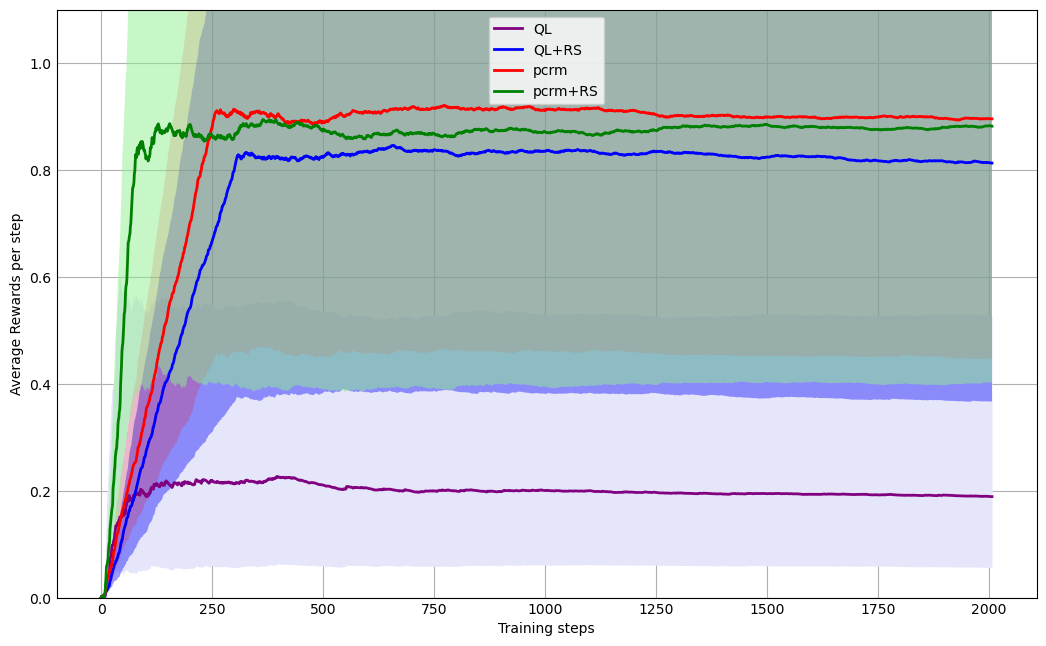

In [52]:
lis = [0, 0.002, 0.002, .001, .001, .001, .005]
res_med = lis + res_med
res_rs_med = lis + res_rs_med
res_pcrm_med = lis + res_pcrm_med
res_pcrm_rs_med = lis + res_pcrm_rs_med
res_p25 = lis + res_p25
res_rs_p25 = lis + res_rs_p25
res_pcrm_p25 = lis + res_pcrm_p25 
res_pcrm_rs_p25 = lis + res_pcrm_rs_p25 
res_p75 = lis + res_p75
res_rs_p75 = lis + res_rs_p75
res_pcrm_p75 = lis + res_pcrm_p75 
res_pcrm_rs_p75 = lis + res_pcrm_rs_p75 
xres = range(len(res_med))

# Set style
plt.style.use('_mpl-gallery')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))  # Set figure size (width, height)

ax.fill_between(xres, res_p25, res_p75, color='Lavender', alpha=1., linewidth=0)
ax.plot(xres, res_med, color='purple', linewidth=2, label='QL')

ax.fill_between(xres, res_rs_p25, res_rs_p75, color='Blue', alpha=.4, linewidth=0)
ax.plot(xres, res_rs_med, color='Blue', linewidth=2, label='QL+RS')

ax.fill_between(xres, res_pcrm_p25, res_pcrm_p75, color='red', alpha=.2, linewidth=0)
ax.plot(xres, res_pcrm_med, color='red', linewidth=2, label='pcrm')

ax.fill_between(xres, res_pcrm_rs_p25, res_pcrm_rs_p75, color='lightgreen', alpha=.5, linewidth=0)
ax.plot(xres, res_pcrm_rs_med, color='green', linewidth=2, label='pcrm+RS')

# Add axis labels
ax.set_xlabel('Training steps')
ax.set_ylabel('Average Rewards per step')
ax.set_ylim([0, 1.1])

# Add legend
ax.legend(loc='upper center')
plt.show()

In [9]:
import os
os.environ["RAY_DISABLE_DASHBOARD"] = "1"

csv_file1 = '5rd_1_base.csv' #'5rd_1_res_pcrm.csv'
csv_file2 = '5rd_1_base.csv'

def run_learn_and_save(flag1, flag2, flag3):
    import torch
    result = learn(CustomEnvironment(), flag1, flag2, flag3)
    
    if isinstance(result, torch.Tensor):
        result = result.cpu().numpy()

    # Create a DataFrame for the result
    df = pd.DataFrame(result)

    # Print for debugging
    print(f"Saving result: {df.shape}")

    # Save or append to the CSV file
    if os.path.exists(csv_file):
        # Append to existing file
        df.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        # Create new file
        df.to_csv(csv_file, mode='w', header=True, index=False)

    return result

# Measure time
t1 = time.time()

# Run the learn function and save the result
result = run_learn_and_save(False, True)

t2 = time.time()
print(f"Time for execution: {t2 - t1:.6f} seconds")

# Verify the file exists
if os.path.exists(csv_file):
    print(f"File {csv_file} successfully created.")
else:
    print(f"File {csv_file} does not exist.")

/opt/anaconda3/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Models are on device: mps:0


2024-08-31 15:15:57,145	INFO worker.py:1781 -- Started a local Ray instance.


(raylet) Warning: The remote function __main__.remote_learn is very large (16 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(remote_learn pid=17865) .
(remote_learn pid=17867) .
(remote_learn pid=17866) .
(remote_learn pid=17872) .
(remote_learn pid=17868) .
(remote_learn pid=17865) .
(remote_learn pid=17867) .
(remote_learn pid=17870) .
(remote_learn pid=17863) .
(remote_learn pid=17869) .
(remote_learn pid=17872) .
(remote_learn pid=17865) .
(remote_learn pid=17864) .
(remote_learn pid=17871) .
(remote_learn pid=17870) .
(remote_learn pid=17872) .
(remote_learn pid=17868) .
(remote_learn pid=17867) .
(remote_learn pid=17863) .
(remote_learn pid=17866) .
(remote_learn pid=17868) .
(remote_learn pid=17865) . [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observa

(raylet) Spilled 2497 MiB, 1245 objects, write throughput 1342 MiB/s. Set RAY_verbose_spill_logs=0 to disable this message.


(remote_learn pid=17867) .
(remote_learn pid=17869) .
(remote_learn pid=17864) .
(remote_learn pid=17872) .
(remote_learn pid=17865) .
(remote_learn pid=17868) .
(remote_learn pid=17871) .
(remote_learn pid=17866) .
(remote_learn pid=17870) .
(remote_learn pid=17868) .
(remote_learn pid=17865) .
(remote_learn pid=17863) .
(remote_learn pid=17867) .
(remote_learn pid=17872) .
(remote_learn pid=17869) .
(remote_learn pid=17866) .
(remote_learn pid=17864) .
(remote_learn pid=17868) .
(remote_learn pid=17865) .
(remote_learn pid=17871) .
(remote_learn pid=17870) .
(remote_learn pid=17869) .
(remote_learn pid=17863) .
(remote_learn pid=17866) .
(remote_learn pid=17865) .
(remote_learn pid=17872) .
(remote_learn pid=17867) .
(remote_learn pid=17869) .
(remote_learn pid=17864) .
(remote_learn pid=17871) .
(remote_learn pid=17865) .
(remote_learn pid=17866) .
(remote_learn pid=17872) .
(remote_learn pid=17868) .
(remote_learn pid=17865) .
(remote_learn pid=17870) .
(remote_learn pid=17867) .
(

KeyboardInterrupt: 

In [12]:
import os
os.environ["RAY_DISABLE_DASHBOARD"] = "1"

csv_file = '5rd_10_res.csv'

def run_learn_and_save(flag1, flag2):
    import torch
    result = learn(CustomEnvironment(), flag1, flag2)
    
    if isinstance(result, torch.Tensor):
        result = result.cpu().numpy()

    # Create a DataFrame for the result
    df = pd.DataFrame(result)

    # Print for debugging
    print(f"Saving result: {df.shape}")

    # Save or append to the CSV file
    if os.path.exists(csv_file):
        # Append to existing file
        df.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        # Create new file
        df.to_csv(csv_file, mode='w', header=True, index=False)

    return result

# Measure time
t1 = time.time()

# Run the learn function and save the result
result = run_learn_and_save(False, False)

t2 = time.time()
print(f"Time for execution: {t2 - t1:.6f} seconds")

# Verify the file exists
if os.path.exists(csv_file):
    print(f"File {csv_file} successfully created.")
else:
    print(f"File {csv_file} does not exist.")

Models are on device: mps:0


2024-08-31 12:43:23,592	INFO worker.py:1781 -- Started a local Ray instance.


(raylet) Warning: The remote function __main__.remote_learn is very large (16 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(remote_learn pid=17327) .
(remote_learn pid=17325) ..
(remote_learn pid=17325) ...
(remote_learn pid=17326) ....
(remote_learn pid=17321) .....
(remote_learn pid=17326) . [repeated 126x across cluster]
(remote_learn pid=17325) .. [repeated 220x across cluster]
(remote_learn pid=17325) ... [repeated 124x across cluster]
(remote_learn pid=17327) .... [repeated 21x across cluster]
(remote_learn pid=17327) . [repeated 114x across cluster]
(remote_learn pid=17325) .. [repeated 246x across cluster]
(remote_learn pid=17325) ... [repeated 110x across cluster]
(remote_learn pid=17329) .... [repeated 21x across cluster]
(remote_learn pid=17326) .....
(remote_learn pid=17325) . [repeated 112x across cluster]
(remote_learn pid=17325) .. [repeated 240x across

In [12]:
import os
os.environ["RAY_DISABLE_DASHBOARD"] = "1"

csv_file = '5rd_5_res_crm.csv'# '5rd_1_res_pcrm.csv'

def run_learn_and_save(flag1, flag2):
    import torch
    result = learn(CustomEnvironment(), flag1, flag2)
    
    if isinstance(result, torch.Tensor):
        result = result.cpu().numpy()

    # Create a DataFrame for the result
    df = pd.DataFrame(result)

    # Print for debugging
    print(f"Saving result: {df.shape}")

    # Save or append to the CSV file
    if os.path.exists(csv_file):
        # Append to existing file
        df.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        # Create new file
        df.to_csv(csv_file, mode='w', header=True, index=False)

    return result

# Measure time
t1 = time.time()

# Run the learn function and save the result
result = run_learn_and_save(True, False)

t2 = time.time()
print(f"Time for execution: {t2 - t1:.6f} seconds")

# Verify the file exists
if os.path.exists(csv_file):
    print(f"File {csv_file} successfully created.")
else:
    print(f"File {csv_file} does not exist.")

Models are on device: mps:0


2024-08-28 17:43:38,111	INFO worker.py:1781 -- Started a local Ray instance.


(raylet) Warning: The remote function __main__.remote_learn is very large (16 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(remote_learn pid=98385) .
(remote_learn pid=98380) .
(remote_learn pid=98382) .
(remote_learn pid=98385) . [repeated 8x across cluster]
(remote_learn pid=98380) .
(remote_learn pid=98383) .
(remote_learn pid=98381) . [repeated 6x across cluster]
(remote_learn pid=98383) . [repeated 3x across cluster]
(remote_learn pid=98376) .
(remote_learn pid=98384) .
(remote_learn pid=98382) . [repeated 6x across cluster]
(remote_learn pid=98383) . [repeated 4x across cluster]
(remote_learn pid=98376) .
(remote_learn pid=98380) .
(remote_learn pid=98379) . [repeated 3x across cluster]
(remote_learn pid=98384) . [repeated 5x across cluster]
(remote_learn pid=98380) . [repeated 2x across cluster]
(remote_learn pid=98383) . [repeated 2x across cluster]
(remote_le

In [13]:
import os
os.environ["RAY_DISABLE_DASHBOARD"] = "1"

csv_file = '5rd_6_res_crm.csv'# '5rd_1_res_pcrm.csv'

def run_learn_and_save(flag1, flag2):
    import torch
    result = learn(CustomEnvironment(), flag1, flag2)
    
    if isinstance(result, torch.Tensor):
        result = result.cpu().numpy()

    # Create a DataFrame for the result
    df = pd.DataFrame(result)

    # Print for debugging
    print(f"Saving result: {df.shape}")

    # Save or append to the CSV file
    if os.path.exists(csv_file):
        # Append to existing file
        df.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        # Create new file
        df.to_csv(csv_file, mode='w', header=True, index=False)

    return result

# Measure time
t1 = time.time()

# Run the learn function and save the result
result = run_learn_and_save(True, False)

t2 = time.time()
print(f"Time for execution: {t2 - t1:.6f} seconds")

# Verify the file exists
if os.path.exists(csv_file):
    print(f"File {csv_file} successfully created.")
else:
    print(f"File {csv_file} does not exist.")

Models are on device: mps:0


2024-08-29 01:07:19,430	INFO worker.py:1781 -- Started a local Ray instance.


(raylet) Warning: The remote function __main__.remote_learn is very large (16 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(remote_learn pid=9224) .
(remote_learn pid=9221) . [repeated 5x across cluster]
(remote_learn pid=9222) . [repeated 6x across cluster]
(remote_learn pid=9219) . [repeated 7x across cluster]
(remote_learn pid=9226) . [repeated 5x across cluster]
(remote_learn pid=9219) . [repeated 4x across cluster]
(remote_learn pid=9222) . [repeated 6x across cluster]
(remote_learn pid=9226) . [repeated 5x across cluster]
(remote_learn pid=9221) . [repeated 4x across cluster]
(remote_learn pid=9218) . [repeated 5x across cluster]
(remote_learn pid=9225) . [repeated 6x across cluster]
(remote_learn pid=9225) . [repeated 5x across cluster]
(remote_learn pid=9224) . [repeated 5x across cluster]
(remote_learn pid=9224) . [repeated 5x across cluster]
(remote_learn pi

In [14]:
import os
os.environ["RAY_DISABLE_DASHBOARD"] = "1"

csv_file = '5rd_7_res_crm.csv'# '5rd_1_res_pcrm.csv'

def run_learn_and_save(flag1, flag2):
    import torch
    result = learn(CustomEnvironment(), flag1, flag2)
    
    if isinstance(result, torch.Tensor):
        result = result.cpu().numpy()

    # Create a DataFrame for the result
    df = pd.DataFrame(result)

    # Print for debugging
    print(f"Saving result: {df.shape}")

    # Save or append to the CSV file
    if os.path.exists(csv_file):
        # Append to existing file
        df.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        # Create new file
        df.to_csv(csv_file, mode='w', header=True, index=False)

    return result

# Measure time
t1 = time.time()

# Run the learn function and save the result
result = run_learn_and_save(True, False)

t2 = time.time()
print(f"Time for execution: {t2 - t1:.6f} seconds")

# Verify the file exists
if os.path.exists(csv_file):
    print(f"File {csv_file} successfully created.")
else:
    print(f"File {csv_file} does not exist.")

Models are on device: mps:0


2024-08-29 13:06:48,011	INFO worker.py:1781 -- Started a local Ray instance.


(raylet) Warning: The remote function __main__.remote_learn is very large (16 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(remote_learn pid=10782) .
(remote_learn pid=10783) . [repeated 2x across cluster]
(remote_learn pid=10785) . [repeated 4x across cluster]
(remote_learn pid=10778) . [repeated 6x across cluster]
(remote_learn pid=10784) . [repeated 2x across cluster]
(remote_learn pid=10785) . [repeated 4x across cluster]
(remote_learn pid=10782) . [repeated 5x across cluster]
(remote_learn pid=10784) .
(remote_learn pid=10783) .
(remote_learn pid=10778) . [repeated 4x across cluster]
(remote_learn pid=10776) . [repeated 5x across cluster]
(remote_learn pid=10777) . [repeated 4x across cluster]
(remote_learn pid=10780) . [repeated 3x across cluster]
(remote_learn pid=10776) . [repeated 3x across cluster]
(remote_learn pid=10777) . [repeated 6x across cluster]
(rem

In [15]:
import os
os.environ["RAY_DISABLE_DASHBOARD"] = "1"

csv_file = '5rd_8_res_crm.csv'# '5rd_1_res_pcrm.csv'

def run_learn_and_save(flag1, flag2):
    import torch
    result = learn(CustomEnvironment(), flag1, flag2)
    
    if isinstance(result, torch.Tensor):
        result = result.cpu().numpy()

    # Create a DataFrame for the result
    df = pd.DataFrame(result)

    # Print for debugging
    print(f"Saving result: {df.shape}")

    # Save or append to the CSV file
    if os.path.exists(csv_file):
        # Append to existing file
        df.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        # Create new file
        df.to_csv(csv_file, mode='w', header=True, index=False)

    return result

# Measure time
t1 = time.time()

# Run the learn function and save the result
result = run_learn_and_save(True, False)

t2 = time.time()
print(f"Time for execution: {t2 - t1:.6f} seconds")

# Verify the file exists
if os.path.exists(csv_file):
    print(f"File {csv_file} successfully created.")
else:
    print(f"File {csv_file} does not exist.")

Models are on device: mps:0


2024-08-30 13:03:18,695	INFO worker.py:1781 -- Started a local Ray instance.


(raylet) Warning: The remote function __main__.remote_learn is very large (16 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(remote_learn pid=13886) .
(remote_learn pid=13882) . [repeated 6x across cluster]
(remote_learn pid=13889) . [repeated 4x across cluster]
(remote_learn pid=13881) .
(remote_learn pid=13886) .
(remote_learn pid=13882) . [repeated 4x across cluster]
(remote_learn pid=13889) . [repeated 4x across cluster]
(remote_learn pid=13881) .
(remote_learn pid=13886) .
(remote_learn pid=13884) . [repeated 3x across cluster]
(remote_learn pid=13889) . [repeated 5x across cluster]
(remote_learn pid=13883) .
(remote_learn pid=13881) .
(remote_learn pid=13887) . [repeated 3x across cluster]
(remote_learn pid=13889) . [repeated 5x across cluster]
(remote_learn pid=13883) . [repeated 2x across cluster]
(remote_learn pid=13884) . [repeated 5x across cluster]
(remote_

In [16]:
import os
os.environ["RAY_DISABLE_DASHBOARD"] = "1"

csv_file = '5rd_9_res_crm.csv'# '5rd_1_res_pcrm.csv'

def run_learn_and_save(flag1, flag2):
    import torch
    result = learn(CustomEnvironment(), flag1, flag2)
    
    if isinstance(result, torch.Tensor):
        result = result.cpu().numpy()

    # Create a DataFrame for the result
    df = pd.DataFrame(result)

    # Print for debugging
    print(f"Saving result: {df.shape}")

    # Save or append to the CSV file
    if os.path.exists(csv_file):
        # Append to existing file
        df.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        # Create new file
        df.to_csv(csv_file, mode='w', header=True, index=False)

    return result

# Measure time
t1 = time.time()

# Run the learn function and save the result
result = run_learn_and_save(True, False)

t2 = time.time()
print(f"Time for execution: {t2 - t1:.6f} seconds")

# Verify the file exists
if os.path.exists(csv_file):
    print(f"File {csv_file} successfully created.")
else:
    print(f"File {csv_file} does not exist.")

Models are on device: mps:0


2024-08-30 19:31:38,870	INFO worker.py:1781 -- Started a local Ray instance.


(raylet) Warning: The remote function __main__.remote_learn is very large (16 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(remote_learn pid=15070) .
(remote_learn pid=15061) . [repeated 9x across cluster]
(remote_learn pid=15063) .
(remote_learn pid=15070) .
(remote_learn pid=15069) . [repeated 9x across cluster]
(remote_learn pid=15070) . [repeated 2x across cluster]
(remote_learn pid=15065) . [repeated 8x across cluster]
(remote_learn pid=15064) . [repeated 4x across cluster]
(remote_learn pid=15070) . [repeated 3x across cluster]
(remote_learn pid=15069) . [repeated 4x across cluster]
(remote_learn pid=15064) . [repeated 4x across cluster]
(remote_learn pid=15062) . [repeated 3x across cluster]
(remote_learn pid=15061) . [repeated 3x across cluster]
(remote_learn pid=15065) . [repeated 3x across cluster]
(remote_learn pid=15070) . [repeated 4x across cluster]
(rem

In [17]:
import os
os.environ["RAY_DISABLE_DASHBOARD"] = "1"

csv_file = '5rd_10_res_crm.csv'# '5rd_1_res_pcrm.csv'

def run_learn_and_save(flag1, flag2):
    import torch
    result = learn(CustomEnvironment(), flag1, flag2)
    
    if isinstance(result, torch.Tensor):
        result = result.cpu().numpy()

    # Create a DataFrame for the result
    df = pd.DataFrame(result)

    # Print for debugging
    print(f"Saving result: {df.shape}")

    # Save or append to the CSV file
    if os.path.exists(csv_file):
        # Append to existing file
        df.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        # Create new file
        df.to_csv(csv_file, mode='w', header=True, index=False)

    return result

# Measure time
t1 = time.time()

# Run the learn function and save the result
result = run_learn_and_save(True, False)

t2 = time.time()
print(f"Time for execution: {t2 - t1:.6f} seconds")

# Verify the file exists
if os.path.exists(csv_file):
    print(f"File {csv_file} successfully created.")
else:
    print(f"File {csv_file} does not exist.")

Models are on device: mps:0


2024-08-31 02:09:43,368	INFO worker.py:1781 -- Started a local Ray instance.


(raylet) Warning: The remote function __main__.remote_learn is very large (16 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(remote_learn pid=16023) .
(remote_learn pid=16021) . [repeated 2x across cluster]
(remote_learn pid=16022) . [repeated 3x across cluster]
(remote_learn pid=16018) . [repeated 4x across cluster]
(remote_learn pid=16019) . [repeated 3x across cluster]
(remote_learn pid=16018) . [repeated 4x across cluster]
(remote_learn pid=16018) . [repeated 3x across cluster]
(remote_learn pid=16019) . [repeated 4x across cluster]
(remote_learn pid=16018) . [repeated 5x across cluster]
(remote_learn pid=16023) . [repeated 3x across cluster]
(remote_learn pid=16017) . [repeated 3x across cluster]
(remote_learn pid=16024) . [repeated 4x across cluster]
(remote_learn pid=16022) . [repeated 4x across cluster]
(remote_learn pid=16023) . [repeated 4x across cluster]
(r